0.003472768590017064 0.017970820695715817 30.095289611514417
0.003472768590017064 0.010375458166230025 30.095289611514545
0.003472768590017064 0.005682872482095371 30.095289611514545
0.003472768590017064 0.003281007957308079 30.095289611514545
0.003472768590017064 0.001797082069571582 30.09528961151448
0.003472768590017064 0.000568287248209537 30.095289611514545


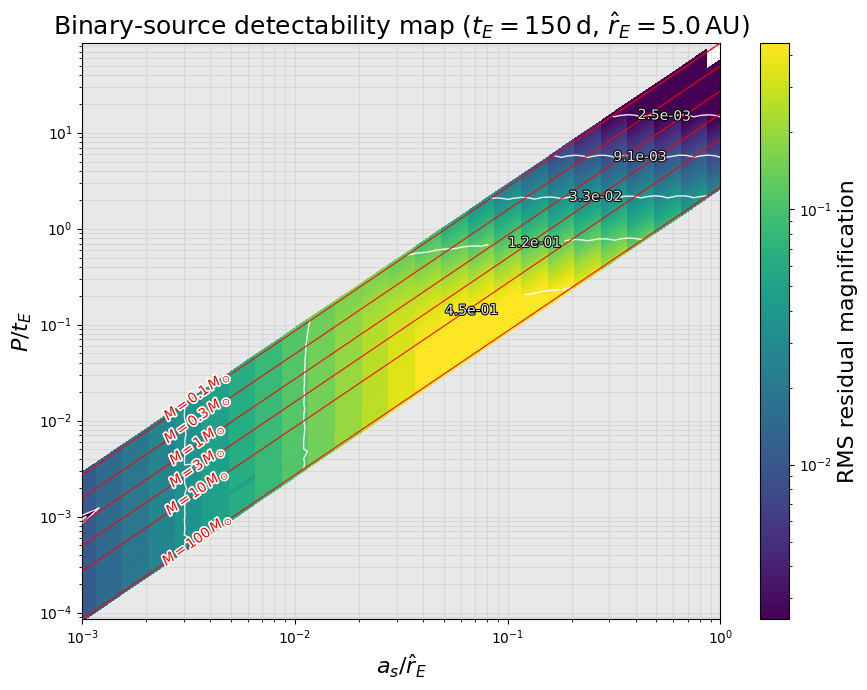

In [1]:
import glob
import os
import re
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as colors
import matplotlib.patheffects as pe

# ============================================================
# Parámetros del barrido
# ============================================================
tE_true = 150.0
rEhat_AU = 5.0

# Estas grillas DEBEN coincidir con las del script de generación
a_over_RE_grid = np.logspace(-3, 0, 25)
Mtot_grid = np.logspace(-1, 2, 30)   # 0.1 a 100 Msun

# rango "físico" que querés remarcar en la figura
Mmin_phys = 0.1
Mmax_phys = 10.0

pattern = f"/home/anibal-pc/binary_source/results/scan_aRE_Mtot_tE{int(tE_true)}/scan_aRE_*_Mtot_*.npz"
files = sorted(glob.glob(pattern))

if len(files) == 0:
    raise FileNotFoundError(f"No encontré archivos con patrón: {pattern}")

# ============================================================
# Parseo de índices desde nombre de archivo
# ============================================================
def extract_indices_from_filename(filename):
    """
    Extrae ia e im desde:
    scan_aRE_003_Mtot_015.npz
    """
    base = os.path.basename(filename)
    m = re.match(r"scan_aRE_(\d+)_Mtot_(\d+)\.npz", base)
    if m is None:
        raise ValueError(f"No pude parsear índices desde: {base}")
    ia = int(m.group(1))
    im = int(m.group(2))
    return ia, im

# ============================================================
# Función para bordes logarítmicos
# ============================================================
def log_bin_edges(x):
    x = np.asarray(x, dtype=float)
    if np.any(x <= 0):
        raise ValueError("Todos los valores deben ser positivos.")
    lx = np.log10(x)
    edges = np.empty(len(x) + 1, dtype=float)
    edges[1:-1] = 0.5 * (lx[:-1] + lx[1:])
    edges[0] = lx[0] - 0.5 * (lx[1] - lx[0])
    edges[-1] = lx[-1] + 0.5 * (lx[-1] - lx[-2])
    return 10**edges

# ============================================================
# Reconstrucción de matrices en la grilla (a_over_RE, Mtot)
# ============================================================
Na = len(a_over_RE_grid)
Nm = len(Mtot_grid)

RMS_map = np.full((Na, Nm), np.nan, dtype=float)
P_over_tE_map = np.full((Na, Nm), np.nan, dtype=float)

for fn in files:
    ia, im = extract_indices_from_filename(fn)

    if not (0 <= ia < Na and 0 <= im < Nm):
        continue

    d = np.load(fn, allow_pickle=False)

    P_grid_file = d["P_grid"].astype(float)
    RMS = d["MAXABS"].astype(float)
    SUCCESS = d["SUCCESS"].astype(bool)

    m = SUCCESS & np.isfinite(P_grid_file) & np.isfinite(RMS)
    if not np.any(m):
        continue

    P_day = float(P_grid_file[m][0])
    rms_val = float(RMS[m][0])

    RMS_map[ia, im] = rms_val
    P_over_tE_map[ia, im] = P_day / tE_true

# ============================================================
# Coordenadas de la grilla en el plano (a_s/R_E, P/t_E)
# ============================================================
A_grid, M_grid = np.meshgrid(a_over_RE_grid, Mtot_grid, indexing="ij")
a_AU_grid = A_grid * rEhat_AU
P_yr_grid = np.sqrt(a_AU_grid**3 / M_grid)
P_day_grid = 365.25 * P_yr_grid
P_over_tE_grid = P_day_grid / tE_true

# ============================================================
# Limpieza conservadora de artefactos de borde
# ============================================================
RMS_map[~np.isfinite(RMS_map)] = np.nan
RMS_map[RMS_map <= 0] = np.nan

positive_all = RMS_map[np.isfinite(RMS_map)]
if len(positive_all) == 0:
    raise RuntimeError("No hay valores positivos de RMS para graficar.")

tiny_threshold = np.percentile(positive_all, 0.5)

border_mask = np.zeros_like(RMS_map, dtype=bool)
border_mask[0, :] = True
border_mask[-1, :] = True
border_mask[:, 0] = True
border_mask[:, -1] = True

RMS_map[border_mask & np.isfinite(RMS_map) & (RMS_map < tiny_threshold)] = np.nan

# ============================================================
# Normalización de color
# ============================================================
positive = RMS_map[np.isfinite(RMS_map) & (RMS_map > 0)]
if len(positive) == 0:
    raise RuntimeError("No quedaron valores positivos de RMS luego de limpiar el mapa.")

vmin = np.percentile(positive, 5)
vmax = np.percentile(positive, 95)

# evita problemas si por percentiles quedan iguales
if vmin <= 0 or vmax <= 0 or np.isclose(vmin, vmax):
    vmin = np.nanmin(positive)
    vmax = np.nanmax(positive)

norm = colors.LogNorm(vmin=vmin, vmax=vmax)

# ============================================================
# Figura
# ============================================================
fig, ax = plt.subplots(figsize=(9, 7))

# ============================================================
# Fondo gris no físico
# ============================================================
x_curve = np.logspace(
    np.log10(a_over_RE_grid.min()),
    np.log10(a_over_RE_grid.max()),
    800
)

def p_over_tE_for_constant_mass(a_over_RE, Mtot_Msun, rEhat_AU, tE_days):
    a_AU = a_over_RE * rEhat_AU
    P_yr = np.sqrt(a_AU**3 / Mtot_Msun)
    P_days = 365.25 * P_yr
    return P_days / tE_days

y_mass_min = p_over_tE_for_constant_mass(x_curve, Mmin_phys, rEhat_AU, tE_true)
y_mass_max = p_over_tE_for_constant_mass(x_curve, Mmax_phys, rEhat_AU, tE_true)

finite_p = P_over_tE_grid[np.isfinite(P_over_tE_grid)]
ymin_plot = np.nanmin(finite_p)
ymax_plot = np.nanmax(finite_p)

# región de masas demasiado bajas: P/tE demasiado grande
ax.fill_between(
    x_curve,
    y_mass_min,
    ymax_plot * np.ones_like(x_curve),
    color="lightgray",
    alpha=0.5,
    zorder=0
)

# región de masas demasiado altas: P/tE demasiado chico
ax.fill_between(
    x_curve,
    ymin_plot * np.ones_like(x_curve),
    y_mass_max,
    color="lightgray",
    alpha=0.5,
    zorder=0
)

# ============================================================
# Mapa coloreado
# ============================================================
a_edges = log_bin_edges(a_over_RE_grid)
m_edges = log_bin_edges(Mtot_grid)

A_edges, M_edges = np.meshgrid(a_edges, m_edges, indexing="ij")
a_AU_edges = A_edges * rEhat_AU
P_yr_edges = np.sqrt(a_AU_edges**3 / M_edges)
P_day_edges = 365.25 * P_yr_edges
P_over_tE_edges = P_day_edges / tE_true

RMS_masked = np.ma.masked_invalid(RMS_map)

pcm = ax.pcolormesh(
    A_edges,
    P_over_tE_edges,
    RMS_masked,
    cmap="viridis",
    norm=norm,
    shading="auto",
    edgecolors="none",
    linewidth=0.0,
    antialiased=False,
    rasterized=True,
    zorder=2
)

# ============================================================
# Contornos con etiquetas
# ============================================================
RMS_for_contour = np.ma.masked_invalid(RMS_map)

contour_levels = np.geomspace(vmin, vmax, 5)

cs = ax.contour(
    A_grid,
    P_over_tE_grid,
    RMS_for_contour,
    levels=contour_levels,
    colors="white",
    linewidths=1.0,
    alpha=0.9,
    norm=norm,
    zorder=3
)

clabels = ax.clabel(
    cs,
    inline=True,
    fontsize=10,
    fmt=lambda x: f"{x:.1e}"
)

for txt in clabels:
    txt.set_path_effects([pe.withStroke(linewidth=1.5, foreground="black")])

# ============================================================
# [NUEVO BLOQUE A]
# curvas de masa a dibujar
# ============================================================
mass_list = [0.1, 0.3, 1.0, 3.0, 10.0, 100.0]
mass_colors = plt.cm.tab10(np.linspace(0, 1, len(mass_list)))

# ============================================================
# [NUEVO BLOQUE B]
# función para elegir la posición del label sobre cada curva
# y calcular el ángulo real en pantalla
# ============================================================
def choose_label_on_curve(ax, x_curve, y_curve, ymin_plot, ymax_plot,
                          y_offset_factor=1.02,
                          slope_loglog=1.5, dlogx=0.08,
                          frac_low=0.18):
    """
    Elige una posición para el label sobre la curva, cerca de la parte
    inferior izquierda pero no pegada al borde inferior.

    frac_low controla qué tan abajo se ubica el label dentro del tramo
    visible de la curva:
        frac_low = 0.0  -> punto más bajo visible
        frac_low = 0.18 -> un poco más arriba
        frac_low = 0.30 -> todavía más arriba
    """
    mask = (
        np.isfinite(x_curve) &
        np.isfinite(y_curve) &
        (y_curve >= ymin_plot) &
        (y_curve <= ymax_plot)
    )

    if np.count_nonzero(mask) < 3:
        return None, None, None

    x_valid = x_curve[mask]
    y_valid = y_curve[mask]

    # ============================================================
    # [NUEVO BLOQUE AGREGADO]
    # elegir un punto bajo de la curva, pero no el mínimo exacto
    # ============================================================
    ly = np.log10(y_valid)
    ly_target = ly.min() + frac_low * (ly.max() - ly.min())
    idx = np.argmin(np.abs(ly - ly_target))
    idx = np.clip(idx, 1, len(x_valid) - 2)

    xlab = x_valid[idx]
    y_on_curve = y_valid[idx]
    ylab = y_on_curve * y_offset_factor

    if not (ymin_plot < ylab < ymax_plot):
        ylab = y_on_curve

    # ============================================================
    # pendiente teórica de Kepler en log-log
    # ============================================================
    x1 = xlab * 10**(-dlogx / 2.0)
    x2 = xlab * 10**(+dlogx / 2.0)

    y1 = y_on_curve * (x1 / xlab)**slope_loglog
    y2 = y_on_curve * (x2 / xlab)**slope_loglog

    p1 = ax.transData.transform((x1, y1))
    p2 = ax.transData.transform((x2, y2))

    dx = p2[0] - p1[0]
    dy = p2[1] - p1[1]

    angle_deg = np.degrees(np.arctan2(dy, dx))

    return xlab, ylab, angle_deg
# ============================================================
# [NUEVO BLOQUE C]
# límites del gráfico
# ============================================================
xmin_plot = a_over_RE_grid.min()
xmax_plot = a_over_RE_grid.max()

# ============================================================
# [NUEVO BLOQUE C0] AGREGADO
# definir escalas y límites ANTES de calcular la rotación de labels
# ============================================================
ax.set_xscale("log")
ax.set_yscale("log")
ax.set_xlim(xmin_plot, xmax_plot)
ax.set_ylim(ymin_plot, ymax_plot)

# forzar a Matplotlib a construir la transformación final data -> display
fig.canvas.draw()

# ============================================================
# [NUEVO BLOQUE C1]
# fracciones x y offsets para distribuir labels
# ============================================================
frac_x_list = [0.62, 0.68, 0.74, 0.80, 0.86, 0.92]
y_offset_list = [1.04, 1.035, 1.03, 1.025, 1.02, 1.015]

# ============================================================
# [NUEVO BLOQUE D]
# curvas de masa constante + labels alineados
# ============================================================
for i, Mtot in enumerate(mass_list):
    curve_color = mass_colors[i]
    y_curve = p_over_tE_for_constant_mass(x_curve, Mtot, rEhat_AU, tE_true)

    mask = (
        np.isfinite(y_curve) &
        (y_curve >= ymin_plot) &
        (y_curve <= ymax_plot)
    )

    if np.any(mask):
        ax.plot(
            x_curve[mask],
            y_curve[mask],
            color="red",
            linewidth=0.8,
            alpha=0.95,
            zorder=4
        )

        xlab, ylab, angle_deg = choose_label_on_curve(
            ax,
            x_curve,
            y_curve,
            ymin_plot=ymin_plot,
            ymax_plot=ymax_plot
        )
        print(xlab,ylab,angle_deg)
        # xlab=np.ones(6)*0.01
        if xlab is not None:
            label = rf"$M={Mtot:g}\,M_\odot$"
            txt = ax.text(
                xlab,
                ylab,
                label,
                color="red",
                fontsize=10,
                ha="center",
                va="center",
                rotation=35,
                rotation_mode="anchor",
                zorder=6
            )
            txt.set_path_effects([
                pe.withStroke(linewidth=2.5, foreground="white")
            ])

# remarcar bordes físicos
ax.plot(x_curve, y_mass_min, color="gray", linewidth=1.0, linestyle="--", zorder=1)
ax.plot(x_curve, y_mass_max, color="gray", linewidth=1.0, linestyle="--", zorder=1)
# t_test = np.linspace(1e-3,1,50)
# f_test = lambda t: t**(3/2)
# ax.plot(t_test, f_test(t_test))
ax.set_xlabel(r"$a_s/\hat{r}_E$", fontsize=16)
ax.set_ylabel(r"$P/t_E$", fontsize=16)
ax.set_title(
    rf"Binary-source detectability map "
    rf"($t_E={tE_true:.0f}\,\mathrm{{d}}$, $\hat r_E={rEhat_AU:.1f}\,\mathrm{{AU}}$)",
    fontsize=18
)

ax.grid(True, which="both", alpha=0.25)

cbar = fig.colorbar(pcm, ax=ax)
cbar.set_label(r"RMS residual magnification", fontsize=16)

# X, Y = np.meshgrid(xiE_grid, P_over_tE_grid)

# threshold = 1e-2   # detectabilidad elegida


plt.tight_layout()
plt.savefig("/home/anibal-pc/grid_rms.png", dpi=250, bbox_inches="tight")
plt.show()

0.003472768590017064 0.017970820695715817 30.095289611514417
0.003472768590017064 0.010375458166230025 30.095289611514545
0.003472768590017064 0.005682872482095371 30.095289611514545
0.003472768590017064 0.003281007957308079 30.095289611514545
0.003472768590017064 0.001797082069571582 30.09528961151448
0.003472768590017064 0.000568287248209537 30.095289611514545


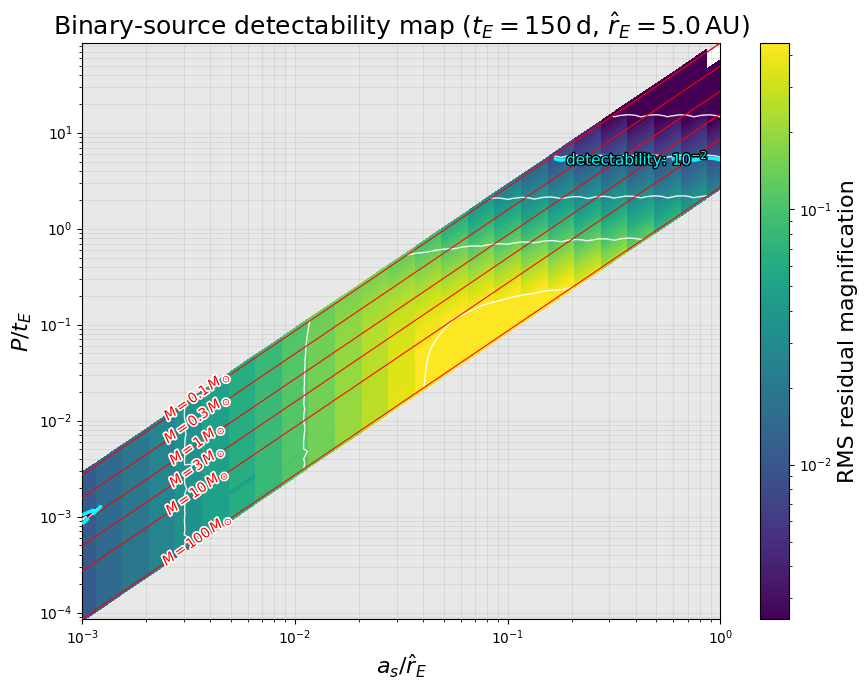

In [2]:
import glob
import os
import re
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as colors
import matplotlib.patheffects as pe

# ============================================================
# Parámetros del barrido
# ============================================================
tE_true = 150.0
rEhat_AU = 5.0

# Estas grillas DEBEN coincidir con las del script de generación
a_over_RE_grid = np.logspace(-3, 0, 25)
Mtot_grid = np.logspace(-1, 2, 30)   # 0.1 a 100 Msun

# rango "físico" que querés remarcar en la figura
Mmin_phys = 0.1
Mmax_phys = 10.0

pattern = f"/home/anibal-pc/binary_source/results/scan_aRE_Mtot_tE{int(tE_true)}/scan_aRE_*_Mtot_*.npz"
files = sorted(glob.glob(pattern))

if len(files) == 0:
    raise FileNotFoundError(f"No encontré archivos con patrón: {pattern}")

# ============================================================
# Parseo de índices desde nombre de archivo
# ============================================================
def extract_indices_from_filename(filename):
    """
    Extrae ia e im desde:
    scan_aRE_003_Mtot_015.npz
    """
    base = os.path.basename(filename)
    m = re.match(r"scan_aRE_(\d+)_Mtot_(\d+)\.npz", base)
    if m is None:
        raise ValueError(f"No pude parsear índices desde: {base}")
    ia = int(m.group(1))
    im = int(m.group(2))
    return ia, im

# ============================================================
# Función para bordes logarítmicos
# ============================================================
def log_bin_edges(x):
    x = np.asarray(x, dtype=float)
    if np.any(x <= 0):
        raise ValueError("Todos los valores deben ser positivos.")
    lx = np.log10(x)
    edges = np.empty(len(x) + 1, dtype=float)
    edges[1:-1] = 0.5 * (lx[:-1] + lx[1:])
    edges[0] = lx[0] - 0.5 * (lx[1] - lx[0])
    edges[-1] = lx[-1] + 0.5 * (lx[-1] - lx[-2])
    return 10**edges

# ============================================================
# Reconstrucción de matrices en la grilla (a_over_RE, Mtot)
# ============================================================
Na = len(a_over_RE_grid)
Nm = len(Mtot_grid)

RMS_map = np.full((Na, Nm), np.nan, dtype=float)
P_over_tE_map = np.full((Na, Nm), np.nan, dtype=float)

for fn in files:
    ia, im = extract_indices_from_filename(fn)

    if not (0 <= ia < Na and 0 <= im < Nm):
        continue

    d = np.load(fn, allow_pickle=False)

    P_grid_file = d["P_grid"].astype(float)
    RMS = d["MAXABS"].astype(float)
    SUCCESS = d["SUCCESS"].astype(bool)

    m = SUCCESS & np.isfinite(P_grid_file) & np.isfinite(RMS)
    if not np.any(m):
        continue

    P_day = float(P_grid_file[m][0])
    rms_val = float(RMS[m][0])

    RMS_map[ia, im] = rms_val
    P_over_tE_map[ia, im] = P_day / tE_true

# ============================================================
# Coordenadas de la grilla en el plano (a_s/R_E, P/t_E)
# ============================================================
A_grid, M_grid = np.meshgrid(a_over_RE_grid, Mtot_grid, indexing="ij")
a_AU_grid = A_grid * rEhat_AU
P_yr_grid = np.sqrt(a_AU_grid**3 / M_grid)
P_day_grid = 365.25 * P_yr_grid
P_over_tE_grid = P_day_grid / tE_true

# ============================================================
# Limpieza conservadora de artefactos de borde
# ============================================================
RMS_map[~np.isfinite(RMS_map)] = np.nan
RMS_map[RMS_map <= 0] = np.nan

positive_all = RMS_map[np.isfinite(RMS_map)]
if len(positive_all) == 0:
    raise RuntimeError("No hay valores positivos de RMS para graficar.")

tiny_threshold = np.percentile(positive_all, 0.5)

border_mask = np.zeros_like(RMS_map, dtype=bool)
border_mask[0, :] = True
border_mask[-1, :] = True
border_mask[:, 0] = True
border_mask[:, -1] = True

RMS_map[border_mask & np.isfinite(RMS_map) & (RMS_map < tiny_threshold)] = np.nan

# ============================================================
# Normalización de color
# ============================================================
positive = RMS_map[np.isfinite(RMS_map) & (RMS_map > 0)]
if len(positive) == 0:
    raise RuntimeError("No quedaron valores positivos de RMS luego de limpiar el mapa.")

vmin = np.percentile(positive, 5)
vmax = np.percentile(positive, 95)

# evita problemas si por percentiles quedan iguales
if vmin <= 0 or vmax <= 0 or np.isclose(vmin, vmax):
    vmin = np.nanmin(positive)
    vmax = np.nanmax(positive)

norm = colors.LogNorm(vmin=vmin, vmax=vmax)

# ============================================================
# Figura
# ============================================================
fig, ax = plt.subplots(figsize=(9, 7))

# ============================================================
# Fondo gris no físico
# ============================================================
x_curve = np.logspace(
    np.log10(a_over_RE_grid.min()),
    np.log10(a_over_RE_grid.max()),
    800
)

def p_over_tE_for_constant_mass(a_over_RE, Mtot_Msun, rEhat_AU, tE_days):
    a_AU = a_over_RE * rEhat_AU
    P_yr = np.sqrt(a_AU**3 / Mtot_Msun)
    P_days = 365.25 * P_yr
    return P_days / tE_days

y_mass_min = p_over_tE_for_constant_mass(x_curve, Mmin_phys, rEhat_AU, tE_true)
y_mass_max = p_over_tE_for_constant_mass(x_curve, Mmax_phys, rEhat_AU, tE_true)

finite_p = P_over_tE_grid[np.isfinite(P_over_tE_grid)]
ymin_plot = np.nanmin(finite_p)
ymax_plot = np.nanmax(finite_p)

# región de masas demasiado bajas: P/tE demasiado grande
ax.fill_between(
    x_curve,
    y_mass_min,
    ymax_plot * np.ones_like(x_curve),
    color="lightgray",
    alpha=0.5,
    zorder=0
)

# región de masas demasiado altas: P/tE demasiado chico
ax.fill_between(
    x_curve,
    ymin_plot * np.ones_like(x_curve),
    y_mass_max,
    color="lightgray",
    alpha=0.5,
    zorder=0
)

# ============================================================
# Mapa coloreado
# ============================================================
a_edges = log_bin_edges(a_over_RE_grid)
m_edges = log_bin_edges(Mtot_grid)

A_edges, M_edges = np.meshgrid(a_edges, m_edges, indexing="ij")
a_AU_edges = A_edges * rEhat_AU
P_yr_edges = np.sqrt(a_AU_edges**3 / M_edges)
P_day_edges = 365.25 * P_yr_edges
P_over_tE_edges = P_day_edges / tE_true

RMS_masked = np.ma.masked_invalid(RMS_map)

pcm = ax.pcolormesh(
    A_edges,
    P_over_tE_edges,
    RMS_masked,
    cmap="viridis",
    norm=norm,
    shading="auto",
    edgecolors="none",
    linewidth=0.0,
    antialiased=False,
    rasterized=True,
    zorder=2
)

# ============================================================
# Contornos con etiquetas
# ============================================================
RMS_for_contour = np.ma.masked_invalid(RMS_map)

contour_levels = np.geomspace(vmin, vmax, 5)

cs = ax.contour(
    A_grid,
    P_over_tE_grid,
    RMS_for_contour,
    levels=contour_levels,
    colors="white",
    linewidths=1.0,
    alpha=0.9,
    norm=norm,
    zorder=3
)

# clabels = ax.clabel(
#     cs,
#     inline=True,
#     fontsize=10,
#     fmt=lambda x: f"{x:.1e}"
# )

# for txt in clabels:
#     txt.set_path_effects([pe.withStroke(linewidth=1.5, foreground="black")])



# ============================================================
# [NUEVO BLOQUE DETECTABILIDAD]
# contorno de detectabilidad para un umbral fijo de RMS
# ============================================================
detect_threshold = 1e-2

if np.nanmin(positive) <= detect_threshold <= np.nanmax(positive):
    cs_detect = ax.contour(
        A_grid,
        P_over_tE_grid,
        RMS_for_contour,
        levels=[detect_threshold],
        colors="cyan",
        linewidths=2.5,
        linestyles="--",
        zorder=5
    )

    detect_labels = ax.clabel(
        cs_detect,
        inline=True,
        fontsize=11,
        fmt={detect_threshold: r"detectability: $10^{-2}$"}
    )

    for txt in detect_labels:
        txt.set_path_effects([pe.withStroke(linewidth=2.0, foreground="black")])
else:
    print(
        f"[INFO] El umbral detect_threshold={detect_threshold:.2e} "
        f"queda fuera del rango del mapa "
        f"[{np.nanmin(positive):.2e}, {np.nanmax(positive):.2e}]. "
        "No se dibuja contorno de detectabilidad."
    )

# ============================================================
# [NUEVO BLOQUE A]
# curvas de masa a dibujar
# ============================================================
mass_list = [0.1, 0.3, 1.0, 3.0, 10.0, 100.0]
mass_colors = plt.cm.tab10(np.linspace(0, 1, len(mass_list)))

# ============================================================
# [NUEVO BLOQUE B]
# función para elegir la posición del label sobre cada curva
# y calcular el ángulo real en pantalla
# ============================================================
def choose_label_on_curve(ax, x_curve, y_curve, ymin_plot, ymax_plot,
                          y_offset_factor=1.02,
                          slope_loglog=1.5, dlogx=0.08,
                          frac_low=0.18):
    """
    Elige una posición para el label sobre la curva, cerca de la parte
    inferior izquierda pero no pegada al borde inferior.

    frac_low controla qué tan abajo se ubica el label dentro del tramo
    visible de la curva:
        frac_low = 0.0  -> punto más bajo visible
        frac_low = 0.18 -> un poco más arriba
        frac_low = 0.30 -> todavía más arriba
    """
    mask = (
        np.isfinite(x_curve) &
        np.isfinite(y_curve) &
        (y_curve >= ymin_plot) &
        (y_curve <= ymax_plot)
    )

    if np.count_nonzero(mask) < 3:
        return None, None, None

    x_valid = x_curve[mask]
    y_valid = y_curve[mask]

    # ============================================================
    # [NUEVO BLOQUE AGREGADO]
    # elegir un punto bajo de la curva, pero no el mínimo exacto
    # ============================================================
    ly = np.log10(y_valid)
    ly_target = ly.min() + frac_low * (ly.max() - ly.min())
    idx = np.argmin(np.abs(ly - ly_target))
    idx = np.clip(idx, 1, len(x_valid) - 2)

    xlab = x_valid[idx]
    y_on_curve = y_valid[idx]
    ylab = y_on_curve * y_offset_factor

    if not (ymin_plot < ylab < ymax_plot):
        ylab = y_on_curve

    # pendiente teórica de Kepler en log-log
    x1 = xlab * 10**(-dlogx / 2.0)
    x2 = xlab * 10**(+dlogx / 2.0)

    y1 = y_on_curve * (x1 / xlab)**slope_loglog
    y2 = y_on_curve * (x2 / xlab)**slope_loglog

    p1 = ax.transData.transform((x1, y1))
    p2 = ax.transData.transform((x2, y2))

    dx = p2[0] - p1[0]
    dy = p2[1] - p1[1]

    angle_deg = np.degrees(np.arctan2(dy, dx))

    return xlab, ylab, angle_deg

# ============================================================
# [NUEVO BLOQUE C]
# límites del gráfico
# ============================================================
xmin_plot = a_over_RE_grid.min()
xmax_plot = a_over_RE_grid.max()

# ============================================================
# [NUEVO BLOQUE C0] AGREGADO
# definir escalas y límites ANTES de calcular la rotación de labels
# ============================================================
ax.set_xscale("log")
ax.set_yscale("log")
ax.set_xlim(xmin_plot, xmax_plot)
ax.set_ylim(ymin_plot, ymax_plot)

# forzar a Matplotlib a construir la transformación final data -> display
fig.canvas.draw()

# ============================================================
# [NUEVO BLOQUE C1]
# fracciones x y offsets para distribuir labels
# ============================================================
frac_x_list = [0.62, 0.68, 0.74, 0.80, 0.86, 0.92]
y_offset_list = [1.04, 1.035, 1.03, 1.025, 1.02, 1.015]

# ============================================================
# [NUEVO BLOQUE D]
# curvas de masa constante + labels alineados
# ============================================================
for i, Mtot in enumerate(mass_list):
    curve_color = mass_colors[i]
    y_curve = p_over_tE_for_constant_mass(x_curve, Mtot, rEhat_AU, tE_true)

    mask = (
        np.isfinite(y_curve) &
        (y_curve >= ymin_plot) &
        (y_curve <= ymax_plot)
    )

    if np.any(mask):
        ax.plot(
            x_curve[mask],
            y_curve[mask],
            color="red",
            linewidth=0.8,
            alpha=0.95,
            zorder=4
        )

        xlab, ylab, angle_deg = choose_label_on_curve(
            ax,
            x_curve,
            y_curve,
            ymin_plot=ymin_plot,
            ymax_plot=ymax_plot
        )

        print(xlab, ylab, angle_deg)

        if xlab is not None:
            label = rf"$M={Mtot:g}\,M_\odot$"
            txt = ax.text(
                xlab,
                ylab,
                label,
                color="red",
                fontsize=10,
                ha="center",
                va="center",
                rotation=35,
                rotation_mode="anchor",
                zorder=6
            )
            txt.set_path_effects([
                pe.withStroke(linewidth=2.5, foreground="white")
            ])

# remarcar bordes físicos
ax.plot(x_curve, y_mass_min, color="gray", linewidth=1.0, linestyle="--", zorder=1)
ax.plot(x_curve, y_mass_max, color="gray", linewidth=1.0, linestyle="--", zorder=1)

ax.set_xlabel(r"$a_s/\hat{r}_E$", fontsize=16)
ax.set_ylabel(r"$P/t_E$", fontsize=16)
ax.set_title(
    rf"Binary-source detectability map "
    rf"($t_E={tE_true:.0f}\,\mathrm{{d}}$, $\hat r_E={rEhat_AU:.1f}\,\mathrm{{AU}}$)",
    fontsize=18
)

ax.grid(True, which="both", alpha=0.25)

cbar = fig.colorbar(pcm, ax=ax)
cbar.set_label(r"RMS residual magnification", fontsize=16)

plt.tight_layout()
plt.savefig("/home/anibal-pc/grid_rms.png", dpi=250, bbox_inches="tight")
plt.show()

0.003472768590017064 0.05391246208714746 30.095289611514545
0.003472768590017064 0.031126374498690077 30.095289611514417
0.003472768590017064 0.01704861744628611 30.09528961151448
0.003472768590017064 0.009843023871924237 30.095289611514545
0.003472768590017064 0.005391246208714746 30.09528961151448
0.003472768590017064 0.0017048617446286112 30.09528961151448


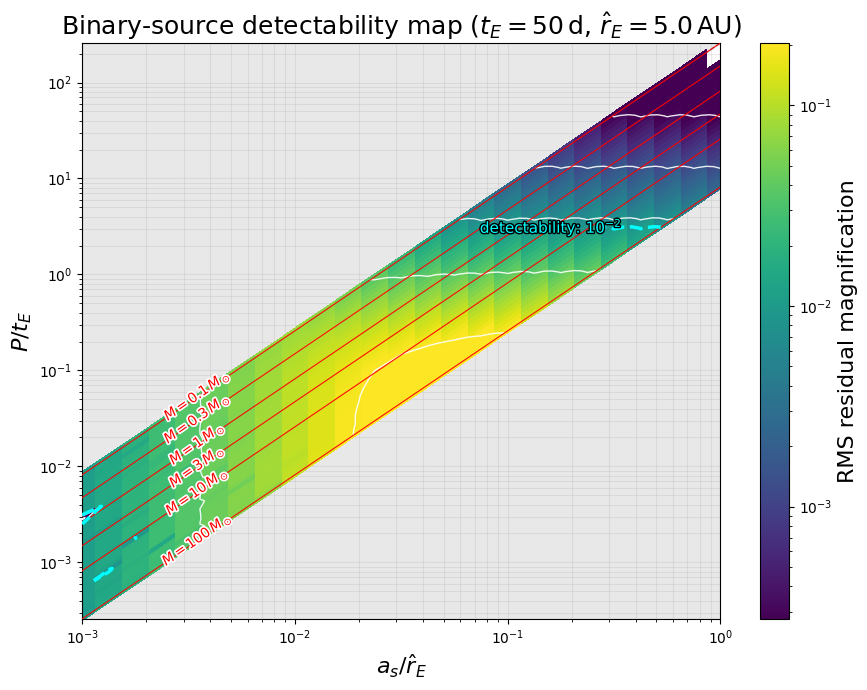

In [3]:
import glob
import os
import re
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as colors
import matplotlib.patheffects as pe

# ============================================================
# Parámetros del barrido
# ============================================================
tE_true = 50.0
rEhat_AU = 5.0

# Estas grillas DEBEN coincidir con las del script de generación
a_over_RE_grid = np.logspace(-3, 0, 25)
Mtot_grid = np.logspace(-1, 2, 30)   # 0.1 a 100 Msun

# rango "físico" que querés remarcar en la figura
Mmin_phys = 0.1
Mmax_phys = 10.0

pattern = f"/home/anibal-pc/binary_source/results/scan_aRE_Mtot_tE{int(tE_true)}/scan_aRE_*_Mtot_*.npz"
files = sorted(glob.glob(pattern))

if len(files) == 0:
    raise FileNotFoundError(f"No encontré archivos con patrón: {pattern}")

# ============================================================
# Parseo de índices desde nombre de archivo
# ============================================================
def extract_indices_from_filename(filename):
    """
    Extrae ia e im desde:
    scan_aRE_003_Mtot_015.npz
    """
    base = os.path.basename(filename)
    m = re.match(r"scan_aRE_(\d+)_Mtot_(\d+)\.npz", base)
    if m is None:
        raise ValueError(f"No pude parsear índices desde: {base}")
    ia = int(m.group(1))
    im = int(m.group(2))
    return ia, im

# ============================================================
# Función para bordes logarítmicos
# ============================================================
def log_bin_edges(x):
    x = np.asarray(x, dtype=float)
    if np.any(x <= 0):
        raise ValueError("Todos los valores deben ser positivos.")
    lx = np.log10(x)
    edges = np.empty(len(x) + 1, dtype=float)
    edges[1:-1] = 0.5 * (lx[:-1] + lx[1:])
    edges[0] = lx[0] - 0.5 * (lx[1] - lx[0])
    edges[-1] = lx[-1] + 0.5 * (lx[-1] - lx[-2])
    return 10**edges

# ============================================================
# Reconstrucción de matrices en la grilla (a_over_RE, Mtot)
# ============================================================
Na = len(a_over_RE_grid)
Nm = len(Mtot_grid)

RMS_map = np.full((Na, Nm), np.nan, dtype=float)
P_over_tE_map = np.full((Na, Nm), np.nan, dtype=float)

for fn in files:
    ia, im = extract_indices_from_filename(fn)

    if not (0 <= ia < Na and 0 <= im < Nm):
        continue

    d = np.load(fn, allow_pickle=False)

    P_grid_file = d["P_grid"].astype(float)
    RMS = d["MAXABS"].astype(float)
    SUCCESS = d["SUCCESS"].astype(bool)

    m = SUCCESS & np.isfinite(P_grid_file) & np.isfinite(RMS)
    if not np.any(m):
        continue

    P_day = float(P_grid_file[m][0])
    rms_val = float(RMS[m][0])

    RMS_map[ia, im] = rms_val
    P_over_tE_map[ia, im] = P_day / tE_true

# ============================================================
# Coordenadas de la grilla en el plano (a_s/R_E, P/t_E)
# ============================================================
A_grid, M_grid = np.meshgrid(a_over_RE_grid, Mtot_grid, indexing="ij")
a_AU_grid = A_grid * rEhat_AU
P_yr_grid = np.sqrt(a_AU_grid**3 / M_grid)
P_day_grid = 365.25 * P_yr_grid
P_over_tE_grid = P_day_grid / tE_true

# ============================================================
# Limpieza conservadora de artefactos de borde
# ============================================================
RMS_map[~np.isfinite(RMS_map)] = np.nan
RMS_map[RMS_map <= 0] = np.nan

positive_all = RMS_map[np.isfinite(RMS_map)]
if len(positive_all) == 0:
    raise RuntimeError("No hay valores positivos de RMS para graficar.")

tiny_threshold = np.percentile(positive_all, 0.5)

border_mask = np.zeros_like(RMS_map, dtype=bool)
border_mask[0, :] = True
border_mask[-1, :] = True
border_mask[:, 0] = True
border_mask[:, -1] = True

RMS_map[border_mask & np.isfinite(RMS_map) & (RMS_map < tiny_threshold)] = np.nan

# ============================================================
# Normalización de color
# ============================================================
positive = RMS_map[np.isfinite(RMS_map) & (RMS_map > 0)]
if len(positive) == 0:
    raise RuntimeError("No quedaron valores positivos de RMS luego de limpiar el mapa.")

vmin = np.percentile(positive, 5)
vmax = np.percentile(positive, 95)

# evita problemas si por percentiles quedan iguales
if vmin <= 0 or vmax <= 0 or np.isclose(vmin, vmax):
    vmin = np.nanmin(positive)
    vmax = np.nanmax(positive)

norm = colors.LogNorm(vmin=vmin, vmax=vmax)

# ============================================================
# Figura
# ============================================================
fig, ax = plt.subplots(figsize=(9, 7))

# ============================================================
# Fondo gris no físico
# ============================================================
x_curve = np.logspace(
    np.log10(a_over_RE_grid.min()),
    np.log10(a_over_RE_grid.max()),
    800
)

def p_over_tE_for_constant_mass(a_over_RE, Mtot_Msun, rEhat_AU, tE_days):
    a_AU = a_over_RE * rEhat_AU
    P_yr = np.sqrt(a_AU**3 / Mtot_Msun)
    P_days = 365.25 * P_yr
    return P_days / tE_days

y_mass_min = p_over_tE_for_constant_mass(x_curve, Mmin_phys, rEhat_AU, tE_true)
y_mass_max = p_over_tE_for_constant_mass(x_curve, Mmax_phys, rEhat_AU, tE_true)

finite_p = P_over_tE_grid[np.isfinite(P_over_tE_grid)]
ymin_plot = np.nanmin(finite_p)
ymax_plot = np.nanmax(finite_p)

# región de masas demasiado bajas: P/tE demasiado grande
ax.fill_between(
    x_curve,
    y_mass_min,
    ymax_plot * np.ones_like(x_curve),
    color="lightgray",
    alpha=0.5,
    zorder=0
)

# región de masas demasiado altas: P/tE demasiado chico
ax.fill_between(
    x_curve,
    ymin_plot * np.ones_like(x_curve),
    y_mass_max,
    color="lightgray",
    alpha=0.5,
    zorder=0
)

# ============================================================
# Mapa coloreado
# ============================================================
a_edges = log_bin_edges(a_over_RE_grid)
m_edges = log_bin_edges(Mtot_grid)

A_edges, M_edges = np.meshgrid(a_edges, m_edges, indexing="ij")
a_AU_edges = A_edges * rEhat_AU
P_yr_edges = np.sqrt(a_AU_edges**3 / M_edges)
P_day_edges = 365.25 * P_yr_edges
P_over_tE_edges = P_day_edges / tE_true

RMS_masked = np.ma.masked_invalid(RMS_map)

pcm = ax.pcolormesh(
    A_edges,
    P_over_tE_edges,
    RMS_masked,
    cmap="viridis",
    norm=norm,
    shading="auto",
    edgecolors="none",
    linewidth=0.0,
    antialiased=False,
    rasterized=True,
    zorder=2
)

# ============================================================
# Contornos con etiquetas
# ============================================================
RMS_for_contour = np.ma.masked_invalid(RMS_map)

contour_levels = np.geomspace(vmin, vmax, 5)

cs = ax.contour(
    A_grid,
    P_over_tE_grid,
    RMS_for_contour,
    levels=contour_levels,
    colors="white",
    linewidths=1.0,
    alpha=0.9,
    norm=norm,
    zorder=3
)

# clabels = ax.clabel(
#     cs,
#     inline=True,
#     fontsize=10,
#     fmt=lambda x: f"{x:.1e}"
# )

# for txt in clabels:
#     txt.set_path_effects([pe.withStroke(linewidth=1.5, foreground="black")])



# ============================================================
# [NUEVO BLOQUE DETECTABILIDAD]
# contorno de detectabilidad para un umbral fijo de RMS
# ============================================================
detect_threshold = 1e-2

if np.nanmin(positive) <= detect_threshold <= np.nanmax(positive):
    cs_detect = ax.contour(
        A_grid,
        P_over_tE_grid,
        RMS_for_contour,
        levels=[detect_threshold],
        colors="cyan",
        linewidths=2.5,
        linestyles="--",
        zorder=5
    )

    detect_labels = ax.clabel(
        cs_detect,
        inline=True,
        fontsize=11,
        fmt={detect_threshold: r"detectability: $10^{-2}$"}
    )

    for txt in detect_labels:
        txt.set_path_effects([pe.withStroke(linewidth=2.0, foreground="black")])
else:
    print(
        f"[INFO] El umbral detect_threshold={detect_threshold:.2e} "
        f"queda fuera del rango del mapa "
        f"[{np.nanmin(positive):.2e}, {np.nanmax(positive):.2e}]. "
        "No se dibuja contorno de detectabilidad."
    )

# ============================================================
# [NUEVO BLOQUE A]
# curvas de masa a dibujar
# ============================================================
mass_list = [0.1, 0.3, 1.0, 3.0, 10.0, 100.0]
mass_colors = plt.cm.tab10(np.linspace(0, 1, len(mass_list)))

# ============================================================
# [NUEVO BLOQUE B]
# función para elegir la posición del label sobre cada curva
# y calcular el ángulo real en pantalla
# ============================================================
def choose_label_on_curve(ax, x_curve, y_curve, ymin_plot, ymax_plot,
                          y_offset_factor=1.02,
                          slope_loglog=1.5, dlogx=0.08,
                          frac_low=0.18):
    """
    Elige una posición para el label sobre la curva, cerca de la parte
    inferior izquierda pero no pegada al borde inferior.

    frac_low controla qué tan abajo se ubica el label dentro del tramo
    visible de la curva:
        frac_low = 0.0  -> punto más bajo visible
        frac_low = 0.18 -> un poco más arriba
        frac_low = 0.30 -> todavía más arriba
    """
    mask = (
        np.isfinite(x_curve) &
        np.isfinite(y_curve) &
        (y_curve >= ymin_plot) &
        (y_curve <= ymax_plot)
    )

    if np.count_nonzero(mask) < 3:
        return None, None, None

    x_valid = x_curve[mask]
    y_valid = y_curve[mask]

    # ============================================================
    # [NUEVO BLOQUE AGREGADO]
    # elegir un punto bajo de la curva, pero no el mínimo exacto
    # ============================================================
    ly = np.log10(y_valid)
    ly_target = ly.min() + frac_low * (ly.max() - ly.min())
    idx = np.argmin(np.abs(ly - ly_target))
    idx = np.clip(idx, 1, len(x_valid) - 2)

    xlab = x_valid[idx]
    y_on_curve = y_valid[idx]
    ylab = y_on_curve * y_offset_factor

    if not (ymin_plot < ylab < ymax_plot):
        ylab = y_on_curve

    # pendiente teórica de Kepler en log-log
    x1 = xlab * 10**(-dlogx / 2.0)
    x2 = xlab * 10**(+dlogx / 2.0)

    y1 = y_on_curve * (x1 / xlab)**slope_loglog
    y2 = y_on_curve * (x2 / xlab)**slope_loglog

    p1 = ax.transData.transform((x1, y1))
    p2 = ax.transData.transform((x2, y2))

    dx = p2[0] - p1[0]
    dy = p2[1] - p1[1]

    angle_deg = np.degrees(np.arctan2(dy, dx))

    return xlab, ylab, angle_deg

# ============================================================
# [NUEVO BLOQUE C]
# límites del gráfico
# ============================================================
xmin_plot = a_over_RE_grid.min()
xmax_plot = a_over_RE_grid.max()

# ============================================================
# [NUEVO BLOQUE C0] AGREGADO
# definir escalas y límites ANTES de calcular la rotación de labels
# ============================================================
ax.set_xscale("log")
ax.set_yscale("log")
ax.set_xlim(xmin_plot, xmax_plot)
ax.set_ylim(ymin_plot, ymax_plot)

# forzar a Matplotlib a construir la transformación final data -> display
fig.canvas.draw()

# ============================================================
# [NUEVO BLOQUE C1]
# fracciones x y offsets para distribuir labels
# ============================================================
frac_x_list = [0.62, 0.68, 0.74, 0.80, 0.86, 0.92]
y_offset_list = [1.04, 1.035, 1.03, 1.025, 1.02, 1.015]

# ============================================================
# [NUEVO BLOQUE D]
# curvas de masa constante + labels alineados
# ============================================================
for i, Mtot in enumerate(mass_list):
    curve_color = mass_colors[i]
    y_curve = p_over_tE_for_constant_mass(x_curve, Mtot, rEhat_AU, tE_true)

    mask = (
        np.isfinite(y_curve) &
        (y_curve >= ymin_plot) &
        (y_curve <= ymax_plot)
    )

    if np.any(mask):
        ax.plot(
            x_curve[mask],
            y_curve[mask],
            color="red",
            linewidth=0.8,
            alpha=0.95,
            zorder=4
        )

        xlab, ylab, angle_deg = choose_label_on_curve(
            ax,
            x_curve,
            y_curve,
            ymin_plot=ymin_plot,
            ymax_plot=ymax_plot
        )

        print(xlab, ylab, angle_deg)

        if xlab is not None:
            label = rf"$M={Mtot:g}\,M_\odot$"
            txt = ax.text(
                xlab,
                ylab,
                label,
                color="red",
                fontsize=10,
                ha="center",
                va="center",
                rotation=35,
                rotation_mode="anchor",
                zorder=6
            )
            txt.set_path_effects([
                pe.withStroke(linewidth=2.5, foreground="white")
            ])

# remarcar bordes físicos
ax.plot(x_curve, y_mass_min, color="gray", linewidth=1.0, linestyle="--", zorder=1)
ax.plot(x_curve, y_mass_max, color="gray", linewidth=1.0, linestyle="--", zorder=1)

ax.set_xlabel(r"$a_s/\hat{r}_E$", fontsize=16)
ax.set_ylabel(r"$P/t_E$", fontsize=16)
ax.set_title(
    rf"Binary-source detectability map "
    rf"($t_E={tE_true:.0f}\,\mathrm{{d}}$, $\hat r_E={rEhat_AU:.1f}\,\mathrm{{AU}}$)",
    fontsize=18
)

ax.grid(True, which="both", alpha=0.25)

cbar = fig.colorbar(pcm, ax=ax)
cbar.set_label(r"RMS residual magnification", fontsize=16)


plt.tight_layout()
plt.savefig("/home/anibal-pc/grid_rms.png", dpi=250, bbox_inches="tight")
plt.show()

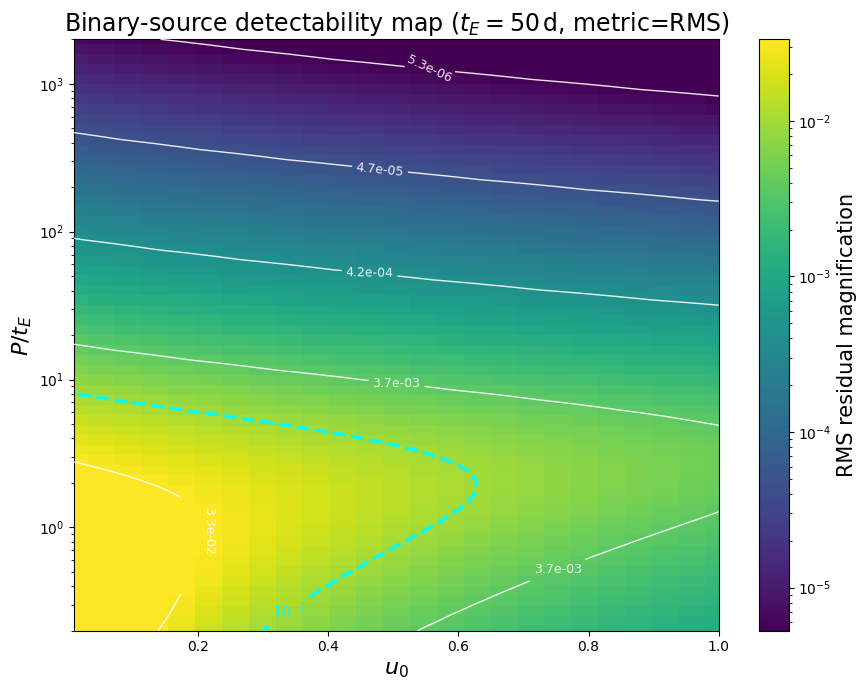

In [4]:
import glob
import os
import re
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as colors

# ============================================================
# [NUEVO BLOQUE 1]
# parámetros del gráfico
# ============================================================
tE_true = 50.0
directory = f"/home/anibal-pc/binary_source/results/scan_u0_tE{int(tE_true)}/"
pattern = os.path.join(directory, "scan_kepler_u0_*.npz")

# si querés usar MAXABS en vez de RMS, cambiá esta variable
metric_key = "RMS"   # opciones típicas: "RMS" o "MAXABS"

files = sorted(glob.glob(pattern))

if len(files) == 0:
    raise FileNotFoundError(f"No encontré archivos con patrón: {pattern}")

# ============================================================
# [NUEVO BLOQUE 2]
# parseo del índice de u0 desde el nombre del archivo
# ============================================================
def extract_u0_index(filename):
    """
    Extrae k desde:
    scan_kepler_u0_003.npz
    """
    base = os.path.basename(filename)
    m = re.match(r"scan_kepler_u0_(\d+)\.npz", base)
    if m is None:
        raise ValueError(f"No pude parsear el índice desde: {base}")
    return int(m.group(1))

# ============================================================
# [NUEVO BLOQUE 3]
# función para bordes lineales
# ============================================================
def linear_bin_edges(x):
    x = np.asarray(x, dtype=float)
    if len(x) < 2:
        raise ValueError("Se necesitan al menos dos puntos para construir bordes.")
    edges = np.empty(len(x) + 1, dtype=float)
    edges[1:-1] = 0.5 * (x[:-1] + x[1:])
    edges[0] = x[0] - 0.5 * (x[1] - x[0])
    edges[-1] = x[-1] + 0.5 * (x[-1] - x[-2])
    return edges

# ============================================================
# [NUEVO BLOQUE 4]
# reconstrucción de u0_grid desde los archivos
# ============================================================
u0_dict = {}
P_grid_ref = None

for fn in files:
    k = extract_u0_index(fn)
    d = np.load(fn, allow_pickle=False)

    truth = d["truth"].astype(float)
    # en tu payload: truth = [t0_true, u0_true, tE_true, ...]
    u0_true = float(truth[1])

    P_grid = d["P_grid"].astype(float)

    if P_grid_ref is None:
        P_grid_ref = P_grid.copy()
    else:
        if len(P_grid) != len(P_grid_ref) or not np.allclose(P_grid, P_grid_ref):
            raise ValueError(f"P_grid no coincide entre archivos. Problema en {fn}")

    u0_dict[k] = u0_true

if len(u0_dict) == 0:
    raise RuntimeError("No se pudo reconstruir u0_grid desde los archivos.")

sorted_indices = np.array(sorted(u0_dict.keys()), dtype=int)
u0_grid = np.array([u0_dict[k] for k in sorted_indices], dtype=float)

Nu0 = len(u0_grid)
NP = len(P_grid_ref)

# ============================================================
# [NUEVO BLOQUE 5]
# construcción del mapa RMS(u0, P/tE)
# ============================================================
RMS_map = np.full((Nu0, NP), np.nan, dtype=float)

index_to_row = {k: i for i, k in enumerate(sorted_indices)}

for fn in files:
    k = extract_u0_index(fn)
    row = index_to_row[k]

    d = np.load(fn, allow_pickle=False)

    P_grid = d["P_grid"].astype(float)
    metric = d[metric_key].astype(float)
    SUCCESS = d["SUCCESS"].astype(bool)

    m = SUCCESS & np.isfinite(P_grid) & np.isfinite(metric) & (metric > 0)
    if not np.any(m):
        continue

    # asumimos que P_grid es común a todos; llenamos solo donde hay datos válidos
    RMS_map[row, m] = metric[m]

# ============================================================
# [NUEVO BLOQUE 6]
# eje vertical en P/tE
# ============================================================
P_over_tE_grid = P_grid_ref / tE_true

# ============================================================
# [NUEVO BLOQUE 7]
# bordes para pcolormesh
# x = u0 (lineal), y = P/tE (log)
# ============================================================
u0_edges = linear_bin_edges(u0_grid)

def log_bin_edges(x):
    x = np.asarray(x, dtype=float)
    if np.any(x <= 0):
        raise ValueError("Todos los valores deben ser positivos para bordes logarítmicos.")
    lx = np.log10(x)
    edges = np.empty(len(x) + 1, dtype=float)
    edges[1:-1] = 0.5 * (lx[:-1] + lx[1:])
    edges[0] = lx[0] - 0.5 * (lx[1] - lx[0])
    edges[-1] = lx[-1] + 0.5 * (lx[-1] - lx[-2])
    return 10**edges

P_over_tE_edges = log_bin_edges(P_over_tE_grid)

# ============================================================
# [NUEVO BLOQUE 8]
# normalización del colormap
# ============================================================
positive = RMS_map[np.isfinite(RMS_map) & (RMS_map > 0)]
if len(positive) == 0:
    raise RuntimeError("No hay valores positivos para graficar.")

vmin = np.percentile(positive, 5)
vmax = np.percentile(positive, 95)

if vmin <= 0 or vmax <= 0 or np.isclose(vmin, vmax):
    vmin = np.nanmin(positive)
    vmax = np.nanmax(positive)

norm = colors.LogNorm(vmin=vmin, vmax=vmax)

# ============================================================
# [NUEVO BLOQUE 9]
# figura principal
# ============================================================
fig, ax = plt.subplots(figsize=(9, 7))

RMS_masked = np.ma.masked_invalid(RMS_map)

# OJO:
# RMS_map tiene forma (Nu0, NP), pero pcolormesh espera Z.shape = (Ny, Nx)
# con x = u0 y y = P/tE => necesitamos transponer
pcm = ax.pcolormesh(
    u0_edges,
    P_over_tE_edges,
    RMS_masked.T,
    cmap="viridis",
    norm=norm,
    shading="auto",
    edgecolors="none",
    linewidth=0.0,
    antialiased=False,
    rasterized=True,
    zorder=2
)

# ============================================================
# [NUEVO BLOQUE 10]
# contornos de RMS
# ============================================================
U0_grid_2d, P_over_tE_grid_2d = np.meshgrid(u0_grid, P_over_tE_grid, indexing="xy")

contour_levels = np.geomspace(vmin, vmax, 5)

cs = ax.contour(
    U0_grid_2d,
    P_over_tE_grid_2d,
    RMS_masked.T,
    levels=contour_levels,
    colors="white",
    linewidths=1.0,
    alpha=0.9,
    zorder=3
)

ax.clabel(
    cs,
    inline=True,
    fontsize=9,
    fmt=lambda x: f"{x:.1e}"
)

# ============================================================
# [NUEVO BLOQUE 11]
# contorno de detectabilidad
# ============================================================
detect_threshold = 1e-2

if np.nanmin(positive) <= detect_threshold <= np.nanmax(positive):
    cs_detect = ax.contour(
        U0_grid_2d,
        P_over_tE_grid_2d,
        RMS_masked.T,
        levels=[detect_threshold],
        colors="cyan",
        linewidths=2.5,
        linestyles="--",
        zorder=4
    )

    ax.clabel(
        cs_detect,
        inline=True,
        fontsize=10,
        fmt={detect_threshold: r"$10^{-2}$"}
    )

# ============================================================
# [NUEVO BLOQUE 12]
# formato de ejes
# ============================================================
ax.set_yscale("log")
ax.set_xlim(u0_grid.min(), u0_grid.max())
ax.set_ylim(P_over_tE_grid.min(), P_over_tE_grid.max())

ax.set_xlabel(r"$u_0$", fontsize=16)
ax.set_ylabel(r"$P/t_E$", fontsize=16)
ax.set_title(
    rf"Binary-source detectability map "
    rf"($t_E={tE_true:.0f}\,\mathrm{{d}}$, metric={metric_key})",
    fontsize=17
)

ax.grid(True, which="both", alpha=0.25)

cbar = fig.colorbar(pcm, ax=ax)
if metric_key == "RMS":
    cbar.set_label(r"RMS residual magnification", fontsize=15)
else:
    cbar.set_label(metric_key, fontsize=15)

plt.tight_layout()
plt.savefig(f"/home/anibal-pc/binary_source/results/u0_vs_PoverTE_{metric_key}_tE{int(tE_true)}.png",
            dpi=250, bbox_inches="tight")
plt.show()

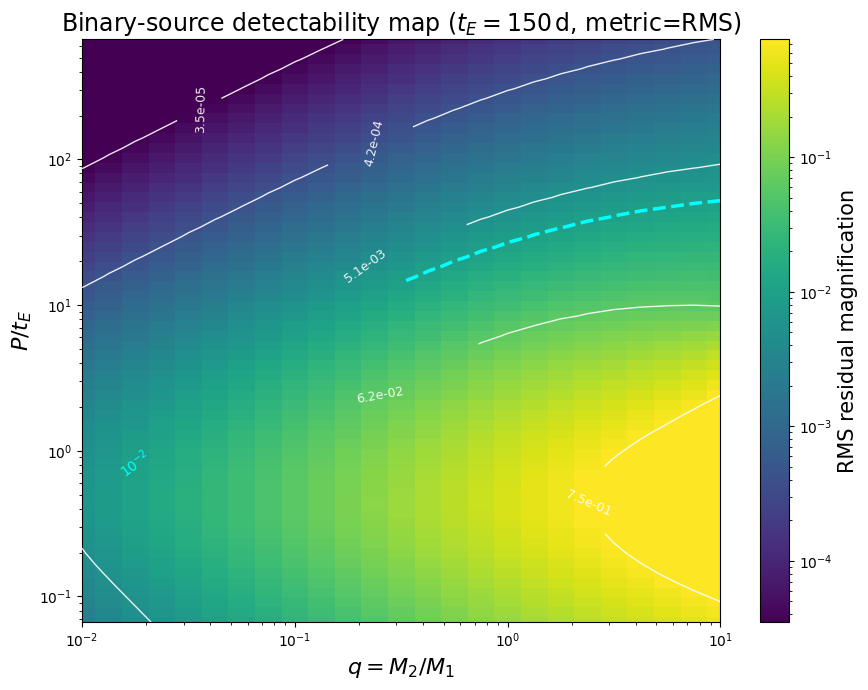

In [6]:
import glob
import os
import re
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as colors

# ============================================================
# [NUEVO BLOQUE 1]
# parámetros del gráfico
# ============================================================
tE_true = 150.0
directory = f"/home/anibal-pc/binary_source/results/scan_q_tE{int(tE_true)}/"
pattern = os.path.join(directory, "scan_kepler_q_*.npz")

metric_key = "RMS"   # o "MAXABS"

files = sorted(glob.glob(pattern))

if len(files) == 0:
    raise FileNotFoundError(f"No encontré archivos con patrón: {pattern}")

# ============================================================
# [NUEVO BLOQUE 2]
# parseo del índice q desde el nombre del archivo
# ============================================================
def extract_q_index(filename):
    """
    Extrae k desde:
    scan_kepler_q_003.npz
    """
    base = os.path.basename(filename)
    m = re.match(r"scan_kepler_q_(\d+)\.npz", base)
    if m is None:
        raise ValueError(f"No pude parsear el índice desde: {base}")
    return int(m.group(1))

# ============================================================
# [NUEVO BLOQUE 3]
# función para bordes logarítmicos
# ============================================================
def log_bin_edges(x):
    x = np.asarray(x, dtype=float)
    if np.any(x <= 0):
        raise ValueError("Todos los valores deben ser positivos.")
    lx = np.log10(x)
    edges = np.empty(len(x) + 1, dtype=float)
    edges[1:-1] = 0.5 * (lx[:-1] + lx[1:])
    edges[0] = lx[0] - 0.5 * (lx[1] - lx[0])
    edges[-1] = lx[-1] + 0.5 * (lx[-1] - lx[-2])
    return 10**edges

# ============================================================
# [NUEVO BLOQUE 4]
# reconstrucción de q_grid desde los archivos
# ============================================================
q_dict = {}
P_grid_ref = None

for fn in files:
    k = extract_q_index(fn)
    d = np.load(fn, allow_pickle=False)

    truth = d["truth"].astype(float)
    M1_true = float(truth[5])
    M2_true = float(truth[6])
    q_true = M2_true / M1_true

    P_grid = d["P_grid"].astype(float)

    if P_grid_ref is None:
        P_grid_ref = P_grid.copy()
    else:
        if len(P_grid) != len(P_grid_ref) or not np.allclose(P_grid, P_grid_ref):
            raise ValueError(f"P_grid no coincide entre archivos. Problema en {fn}")

    q_dict[k] = q_true

if len(q_dict) == 0:
    raise RuntimeError("No se pudo reconstruir q_grid desde los archivos.")

sorted_indices = np.array(sorted(q_dict.keys()), dtype=int)
q_grid = np.array([q_dict[k] for k in sorted_indices], dtype=float)

Nq = len(q_grid)
NP = len(P_grid_ref)

# ============================================================
# [NUEVO BLOQUE 5]
# construcción del mapa RMS(q, P/tE)
# ============================================================
RMS_map = np.full((Nq, NP), np.nan, dtype=float)

index_to_row = {k: i for i, k in enumerate(sorted_indices)}

for fn in files:
    k = extract_q_index(fn)
    row = index_to_row[k]

    d = np.load(fn, allow_pickle=False)

    P_grid = d["P_grid"].astype(float)
    metric = d[metric_key].astype(float)
    SUCCESS = d["SUCCESS"].astype(bool)

    m = SUCCESS & np.isfinite(P_grid) & np.isfinite(metric) & (metric > 0)
    if not np.any(m):
        continue

    RMS_map[row, m] = metric[m]

# ============================================================
# [NUEVO BLOQUE 6]
# eje vertical en P/tE
# ============================================================
P_over_tE_grid = P_grid_ref / tE_true

# ============================================================
# [NUEVO BLOQUE 7]
# bordes para pcolormesh
# x = q (log), y = P/tE (log)
# ============================================================
q_edges = log_bin_edges(q_grid)
P_over_tE_edges = log_bin_edges(P_over_tE_grid)

# ============================================================
# [NUEVO BLOQUE 8]
# normalización del colormap
# ============================================================
positive = RMS_map[np.isfinite(RMS_map) & (RMS_map > 0)]
if len(positive) == 0:
    raise RuntimeError("No hay valores positivos para graficar.")

vmin = np.percentile(positive, 5)
vmax = np.percentile(positive, 95)

if vmin <= 0 or vmax <= 0 or np.isclose(vmin, vmax):
    vmin = np.nanmin(positive)
    vmax = np.nanmax(positive)

norm = colors.LogNorm(vmin=vmin, vmax=vmax)

# ============================================================
# [NUEVO BLOQUE 9]
# figura principal
# ============================================================
fig, ax = plt.subplots(figsize=(9, 7))

RMS_masked = np.ma.masked_invalid(RMS_map)

# RMS_map shape = (Nq, NP)
# x=q, y=P/tE -> hace falta transponer
pcm = ax.pcolormesh(
    q_edges,
    P_over_tE_edges,
    RMS_masked.T,
    cmap="viridis",
    norm=norm,
    shading="auto",
    edgecolors="none",
    linewidth=0.0,
    antialiased=False,
    rasterized=True,
    zorder=2
)

# ============================================================
# [NUEVO BLOQUE 10]
# contornos
# ============================================================
Q_grid_2d, P_over_tE_grid_2d = np.meshgrid(q_grid, P_over_tE_grid, indexing="xy")

contour_levels = np.geomspace(vmin, vmax, 5)

cs = ax.contour(
    Q_grid_2d,
    P_over_tE_grid_2d,
    RMS_masked.T,
    levels=contour_levels,
    colors="white",
    linewidths=1.0,
    alpha=0.9,
    zorder=3
)

ax.clabel(
    cs,
    inline=True,
    fontsize=9,
    fmt=lambda x: f"{x:.1e}"
)

# ============================================================
# [NUEVO BLOQUE 11]
# contorno de detectabilidad
# ============================================================
detect_threshold = 1e-2

if np.nanmin(positive) <= detect_threshold <= np.nanmax(positive):
    cs_detect = ax.contour(
        Q_grid_2d,
        P_over_tE_grid_2d,
        RMS_masked.T,
        levels=[detect_threshold],
        colors="cyan",
        linewidths=2.5,
        linestyles="--",
        zorder=4
    )

    ax.clabel(
        cs_detect,
        inline=True,
        fontsize=10,
        fmt={detect_threshold: r"$10^{-2}$"}
    )

# ============================================================
# [NUEVO BLOQUE 12]
# formato de ejes
# ============================================================
ax.set_xscale("log")
ax.set_yscale("log")
ax.set_xlim(q_grid.min(), q_grid.max())
ax.set_ylim(P_over_tE_grid.min(), P_over_tE_grid.max())

ax.set_xlabel(r"$q=M_2/M_1$", fontsize=16)
ax.set_ylabel(r"$P/t_E$", fontsize=16)
ax.set_title(
    rf"Binary-source detectability map "
    rf"($t_E={tE_true:.0f}\,\mathrm{{d}}$, metric={metric_key})",
    fontsize=17
)

ax.grid(True, which="both", alpha=0.25)

cbar = fig.colorbar(pcm, ax=ax)
if metric_key == "RMS":
    cbar.set_label(r"RMS residual magnification", fontsize=15)
else:
    cbar.set_label(metric_key, fontsize=15)

plt.tight_layout()
plt.savefig(
    f"/home/anibal-pc/binary_source/results/q_vs_PoverTE_{metric_key}_tE{int(tE_true)}.png",
    dpi=250,
    bbox_inches="tight"
)
plt.show()

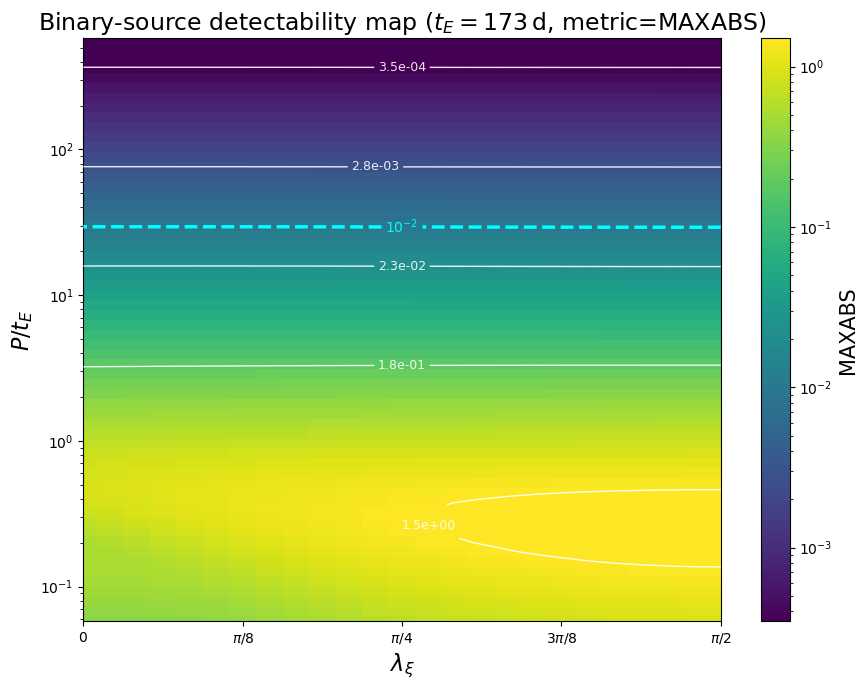

In [9]:
import glob
import os
import re
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as colors

# ============================================================
# Parámetros del gráfico
# ============================================================
tE_true = 173.0
directory = os.path.expanduser(f"~/binary_source/results/scan_lambda_tE{int(tE_true)}/")
pattern = os.path.join(directory, "scan_kepler_lambda_*.npz")

# métrica a mostrar
metric_key = "MAXABS"   # también podrías usar "MAXABS"

files = sorted(glob.glob(pattern))

if len(files) == 0:
    raise FileNotFoundError(f"No encontré archivos con patrón: {pattern}")

# ============================================================
# Parseo del índice lambda desde el nombre del archivo
# ============================================================
def extract_lambda_index(filename):
    """
    Extrae k desde:
    scan_kepler_lambda_003.npz
    """
    base = os.path.basename(filename)
    m = re.match(r"scan_kepler_lambda_(\d+)\.npz", base)
    if m is None:
        raise ValueError(f"No pude parsear el índice desde: {base}")
    return int(m.group(1))

# ============================================================
# Bordes lineales
# ============================================================
def linear_bin_edges(x):
    x = np.asarray(x, dtype=float)
    if len(x) < 2:
        raise ValueError("Se necesitan al menos dos puntos para construir bordes.")
    edges = np.empty(len(x) + 1, dtype=float)
    edges[1:-1] = 0.5 * (x[:-1] + x[1:])
    edges[0] = x[0] - 0.5 * (x[1] - x[0])
    edges[-1] = x[-1] + 0.5 * (x[-1] - x[-2])
    return edges

# ============================================================
# Bordes logarítmicos
# ============================================================
def log_bin_edges(x):
    x = np.asarray(x, dtype=float)
    if np.any(x <= 0):
        raise ValueError("Todos los valores deben ser positivos para usar bordes logarítmicos.")
    lx = np.log10(x)
    edges = np.empty(len(x) + 1, dtype=float)
    edges[1:-1] = 0.5 * (lx[:-1] + lx[1:])
    edges[0] = lx[0] - 0.5 * (lx[1] - lx[0])
    edges[-1] = lx[-1] + 0.5 * (lx[-1] - lx[-2])
    return 10**edges

# ============================================================
# Reconstrucción de lambda_xi_grid desde los archivos
# ============================================================
lambda_dict = {}
P_grid_ref = None

for fn in files:
    k = extract_lambda_index(fn)
    d = np.load(fn, allow_pickle=False)

    truth = d["truth"].astype(float)
    # según cómo guardaste truth:
    # truth = [t0_true, u0_true, tE_true, phi_true, i_true, ...]
    lambda_xi = float(truth[4])

    P_grid = d["P_grid"].astype(float)

    if P_grid_ref is None:
        P_grid_ref = P_grid.copy()
    else:
        if len(P_grid) != len(P_grid_ref) or not np.allclose(P_grid, P_grid_ref):
            raise ValueError(f"P_grid no coincide entre archivos. Problema en {fn}")

    lambda_dict[k] = lambda_xi

if len(lambda_dict) == 0:
    raise RuntimeError("No se pudo reconstruir lambda_xi_grid desde los archivos.")

sorted_indices = np.array(sorted(lambda_dict.keys()), dtype=int)
lambda_xi_grid = np.array([lambda_dict[k] for k in sorted_indices], dtype=float)

Nlam = len(lambda_xi_grid)
NP = len(P_grid_ref)

# ============================================================
# Construcción del mapa RMS(lambda_xi, P/tE)
# ============================================================
RMS_map = np.full((Nlam, NP), np.nan, dtype=float)

index_to_row = {k: i for i, k in enumerate(sorted_indices)}

for fn in files:
    k = extract_lambda_index(fn)
    row = index_to_row[k]

    d = np.load(fn, allow_pickle=False)

    P_grid = d["P_grid"].astype(float)
    metric = d[metric_key].astype(float)
    SUCCESS = d["SUCCESS"].astype(bool)

    m = SUCCESS & np.isfinite(P_grid) & np.isfinite(metric) & (metric > 0)
    if not np.any(m):
        continue

    RMS_map[row, m] = metric[m]

# ============================================================
# Eje vertical en P/tE
# ============================================================
P_over_tE_grid = P_grid_ref / tE_true

# ============================================================
# Bordes para pcolormesh
# x = lambda_xi (lineal)
# y = P/tE (log)
# ============================================================
lambda_edges = linear_bin_edges(lambda_xi_grid)
P_over_tE_edges = log_bin_edges(P_over_tE_grid)

# ============================================================
# Normalización del colormap
# ============================================================
positive = RMS_map[np.isfinite(RMS_map) & (RMS_map > 0)]
if len(positive) == 0:
    raise RuntimeError("No hay valores positivos para graficar.")

vmin = np.percentile(positive, 5)
vmax = np.percentile(positive, 95)

if vmin <= 0 or vmax <= 0 or np.isclose(vmin, vmax):
    vmin = np.nanmin(positive)
    vmax = np.nanmax(positive)

norm = colors.LogNorm(vmin=vmin, vmax=vmax)

# ============================================================
# Figura
# ============================================================
fig, ax = plt.subplots(figsize=(9, 7))

RMS_masked = np.ma.masked_invalid(RMS_map)

# OJO:
# RMS_map tiene forma (Nlam, NP)
# x = lambda_xi, y = P/tE
# entonces Z debe ser (Ny, Nx) = (NP, Nlam), por eso transpose
pcm = ax.pcolormesh(
    lambda_edges,
    P_over_tE_edges,
    RMS_masked.T,
    cmap="viridis",
    norm=norm,
    shading="auto",
    edgecolors="none",
    linewidth=0.0,
    antialiased=False,
    rasterized=True,
    zorder=2
)

# ============================================================
# Contornos de RMS
# ============================================================
LAM_grid_2d, P_over_tE_grid_2d = np.meshgrid(lambda_xi_grid, P_over_tE_grid, indexing="xy")

contour_levels = np.geomspace(vmin, vmax, 5)

cs = ax.contour(
    LAM_grid_2d,
    P_over_tE_grid_2d,
    RMS_masked.T,
    levels=contour_levels,
    colors="white",
    linewidths=1.0,
    alpha=0.9,
    zorder=3
)

ax.clabel(
    cs,
    inline=True,
    fontsize=9,
    fmt=lambda x: f"{x:.1e}"
)

# ============================================================
# Contorno de detectabilidad
# ============================================================
detect_threshold = 1e-2

if np.nanmin(positive) <= detect_threshold <= np.nanmax(positive):
    cs_detect = ax.contour(
        LAM_grid_2d,
        P_over_tE_grid_2d,
        RMS_masked.T,
        levels=[detect_threshold],
        colors="cyan",
        linewidths=2.5,
        linestyles="--",
        zorder=4
    )

    ax.clabel(
        cs_detect,
        inline=True,
        fontsize=10,
        fmt={detect_threshold: r"$10^{-2}$"}
    )

# ============================================================
# Formato de ejes
# ============================================================
ax.set_yscale("log")
ax.set_xlim(lambda_xi_grid.min(), lambda_xi_grid.max())
ax.set_ylim(P_over_tE_grid.min(), P_over_tE_grid.max())

# ticks útiles para lambda_xi
xticks = [0, np.pi/8, np.pi/4, 3*np.pi/8, np.pi/2]
xtick_labels = [
    r"$0$",
    r"$\pi/8$",
    r"$\pi/4$",
    r"$3\pi/8$",
    r"$\pi/2$"
]
ax.set_xticks(xticks)
ax.set_xticklabels(xtick_labels)

ax.set_xlabel(r"$\lambda_\xi$", fontsize=16)
ax.set_ylabel(r"$P/t_E$", fontsize=16)
ax.set_title(
    rf"Binary-source detectability map "
    rf"($t_E={tE_true:.0f}\,\mathrm{{d}}$, metric={metric_key})",
    fontsize=17
)

ax.grid(True, which="both", alpha=0.25)

cbar = fig.colorbar(pcm, ax=ax)
if metric_key == "RMS":
    cbar.set_label(r"RMS residual magnification", fontsize=15)
else:
    cbar.set_label(metric_key, fontsize=15)

plt.tight_layout()
plt.savefig(
    os.path.join(directory, f"lambda_vs_PoverTE_{metric_key}_tE{int(tE_true)}.png"),
    dpi=250,
    bbox_inches="tight"
)
plt.show()

In [14]:
# ============================================================
# Path robusto
# ============================================================
tE_true =50
directory = os.path.expanduser(
    f"~/binary_source/results/scan_q_Mtotfixed_tE{int(tE_true)}/"
)

pattern = os.path.join(directory, "scan_kepler_q_*.npz")

files = sorted(glob.glob(pattern))

print("Archivos encontrados:", len(files))

if len(files) == 0:
    raise FileNotFoundError(f"No encontré archivos en:\n{pattern}")

# ============================================================
# Inicialización segura
# ============================================================
P_grid_ref = None
q_dict = {}

for fn in files:
    print("Leyendo:", fn)   # <-- debug útil

    d = np.load(fn, allow_pickle=False)

    P_grid = d["P_grid"]

    if P_grid_ref is None:
        P_grid_ref = P_grid.copy()

    truth = d["truth"]
    M1, M2 = truth[5], truth[6]
    q = M2 / M1

    k = extract_q_index(fn)
    q_dict[k] = q

# chequeo final
if P_grid_ref is None:
    raise RuntimeError("No se pudo construir P_grid_ref. Revisar archivos.")

Archivos encontrados: 4
Leyendo: /home/anibal/binary_source/results/scan_q_Mtotfixed_tE50/scan_kepler_q_000.npz
Leyendo: /home/anibal/binary_source/results/scan_q_Mtotfixed_tE50/scan_kepler_q_001.npz
Leyendo: /home/anibal/binary_source/results/scan_q_Mtotfixed_tE50/scan_kepler_q_002.npz
Leyendo: /home/anibal/binary_source/results/scan_q_Mtotfixed_tE50/scan_kepler_q_003.npz


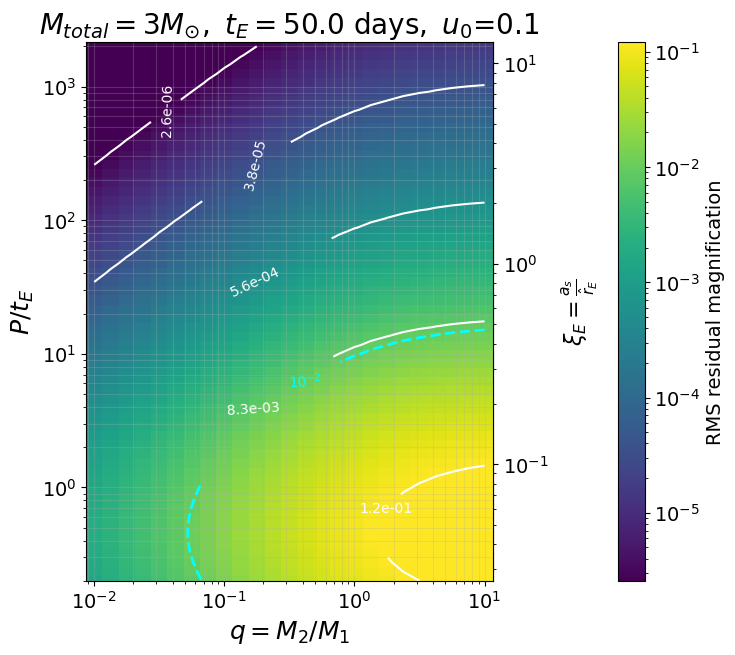

In [41]:
import glob
import os
import re
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as colors
plt.rcParams.update({
    "xtick.labelsize": 14,
    "ytick.labelsize": 14
})
# ============================================================
# Parámetros físicos (IMPORTANTES para xiE)
# ============================================================
tE_true = 50.0
Mtot_fixed = 3.0
rEhat_AU = 5.0

directory = f"/home/anibal/binary_source/results/scan_q_Mtotfixed_tE{int(tE_true)}/"
pattern = os.path.join(directory, "scan_kepler_q_*.npz")

metric_key = "RMS"

files = sorted(glob.glob(pattern))

# ============================================================
# Funciones P/tE <-> xiE
# ============================================================
def xiE_from_PoverTE(P_over_tE):
    P_days = P_over_tE * tE_true
    P_yr = P_days / 365.25
    a_AU = (Mtot_fixed * P_yr**2)**(1/3)
    return a_AU / rEhat_AU

def PoverTE_from_xiE(xiE):
    a_AU = xiE * rEhat_AU
    P_yr = np.sqrt(a_AU**3 / Mtot_fixed)
    P_days = 365.25 * P_yr
    return P_days / tE_true

# ============================================================
# Parseo q
# ============================================================
def extract_q_index(filename):
    base = os.path.basename(filename)
    m = re.match(r"scan_kepler_q_(\d+)\.npz", base)
    return int(m.group(1))

# ============================================================
# Bordes log
# ============================================================
def log_bin_edges(x):
    lx = np.log10(x)
    edges = np.empty(len(x)+1)
    edges[1:-1] = 0.5*(lx[:-1] + lx[1:])
    edges[0] = lx[0] - 0.5*(lx[1]-lx[0])
    edges[-1] = lx[-1] + 0.5*(lx[-1]-lx[-2])
    return 10**edges

# ============================================================
# Leer grilla
# ============================================================
q_dict = {}
P_grid_ref = None

for fn in files:
    k = extract_q_index(fn)
    d = np.load(fn)

    truth = d["truth"]
    M1, M2 = truth[5], truth[6]
    q = M2 / M1

    P_grid = d["P_grid"]

    if P_grid_ref is None:
        P_grid_ref = P_grid.copy()

    q_dict[k] = q

sorted_indices = sorted(q_dict.keys())
q_grid = np.array([q_dict[k] for k in sorted_indices])

Nq = len(q_grid)
NP = len(P_grid_ref)

RMS_map = np.full((Nq, NP), np.nan)

index_to_row = {k: i for i, k in enumerate(sorted_indices)}

for fn in files:
    k = extract_q_index(fn)
    row = index_to_row[k]

    d = np.load(fn)

    metric = d[metric_key]
    SUCCESS = d["SUCCESS"]

    m = SUCCESS & np.isfinite(metric) & (metric > 0)

    RMS_map[row, m] = metric[m]

# ============================================================
# Ejes
# ============================================================
P_over_tE = P_grid_ref / tE_true

q_edges = log_bin_edges(q_grid)
P_edges = log_bin_edges(P_over_tE)

# ============================================================
# Colormap
# ============================================================
positive = RMS_map[np.isfinite(RMS_map) & (RMS_map > 0)]

vmin = np.percentile(positive, 5)
vmax = np.percentile(positive, 95)

norm = colors.LogNorm(vmin=vmin, vmax=vmax)

# ============================================================
# Figura
# ============================================================
fig, ax = plt.subplots(figsize=(9, 7))

pcm = ax.pcolormesh(
    q_edges,
    P_edges,
    np.ma.masked_invalid(RMS_map).T,
    cmap="viridis",
    norm=norm,
    shading="auto"
)

# ============================================================
# Contornos RMS
# ============================================================
Q2d, P2d = np.meshgrid(q_grid, P_over_tE, indexing="xy")

levels = np.geomspace(vmin, vmax, 5)

cs = ax.contour(Q2d, P2d, RMS_map.T, levels=levels, colors="white")
ax.clabel(cs, fmt=lambda x: f"{x:.1e}")

# ============================================================
# Detectabilidad
# ============================================================
threshold = 1e-2

cs_det = ax.contour(
    Q2d, P2d, RMS_map.T,
    levels=[threshold],
    colors="cyan",
    linewidths=2,
    linestyles="--"
)

ax.clabel(cs_det, fmt={threshold: r"$10^{-2}$"})

# ============================================================
# EJE DERECHO (xiE)
# ============================================================
secax = ax.secondary_yaxis(
    'right',
    functions=(xiE_from_PoverTE, PoverTE_from_xiE)
)

secax.set_ylabel(r"$\xi_E = \frac{a_s}{\hat{r}_E}$", fontsize=16, labelpad=8)
secax.set_yscale("log")
secax.tick_params(axis='y', which='both', pad=4)

# ============================================================
# Formato
# ============================================================
ax.set_xscale("log")
ax.set_yscale("log")

ax.set_xlabel(r"$q=M_2/M_1$", fontsize=18)
ax.set_ylabel(r"$P/t_E$", fontsize=18)

ax.grid(True, which="both", alpha=0.25)

# dejar más espacio a la derecha para el eje secundario
fig.subplots_adjust(right=0.82)
plt.title("$M_{total} = 3M_{\odot},\ t_E=$"+f"{tE_true} days"+"$,\ u_0$=0.1",fontsize=20)
# colorbar más separado
cbar = fig.colorbar(pcm, ax=ax, pad=0.2)
cbar.set_label(r"RMS residual magnification", fontsize=14)

plt.show()